In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import make_scorer, f1_score
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, average_precision_score

In [3]:
train_data = load_npz('x_train_cat_tfidf.npz')
test_data  = load_npz('x_test_cat_tfidf.npz')

X_train = train_data[:, :-1]
y_train = np.array(train_data[:, -1].todense()).ravel().astype(int)

X_test = test_data[:, :-1]
y_test = np.array(test_data[:, -1].todense()).ravel().astype(int)

n = len(np.unique(y_train))

In [ ]:
def modelfit(model, X_train, y_train, X_test, y_test):
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=67, stratify=y_train)
    model.fit(X_tr, y_tr,eval_set=[(X_tr, y_tr), (X_val, y_val)])
    results = model.evals_result()
    train_loss = results['validation_0']['mlogloss']
    val_loss   = results['validation_1']['mlogloss']
    best_n = model.best_iteration + 1
    plt.plot(train_loss, label='train mlogloss')
    plt.plot(val_loss,   label='val mlogloss')
    plt.axvline(best_n - 1, label= f'лучший {best_n}')
    plt.xlabel('число деревьев')
    plt.ylabel('mlogloss')
    plt.legend()
    model.set_params(n_estimators=best_n, early_stopping_rounds=None)
    model.fit(X_train, y_train)
    train_proba = model.predict_proba(X_train)
    test_proba = model.predict_proba(X_test)
    train_auc = roc_auc_score(y_train, train_proba, multi_class='ovr', average='macro')
    test_auc = roc_auc_score(y_test,  test_proba, multi_class='ovr', average='macro')
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print('лучшие n estimators:', best_n)
    print('треин рок аук макро:', train_auc)
    print('тест рок аук макро:', test_auc)
    print('аккураси:', test_acc)

    return model

## подбор n_estimators через раннюю остановку

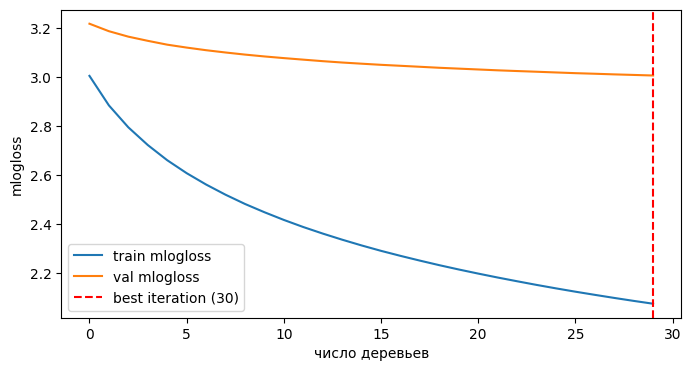

лучшие n estimators: 30
треин рок аук макро: 0.9074
тест рок аук макро: 0.8918
аккураси: 0.4656


In [5]:
model_xgb = XGBClassifier(
    learning_rate=0.1,n_estimators=30,objective='multi:softprob',num_class=n,eval_metric='mlogloss',
    early_stopping_rounds=5,tree_method='hist',n_jobs=-1,random_state=67)
model_xgb = modelfit(model_xgb, X_train, y_train, X_test, y_test)

видим что оно падает, значит стоит брать сильно больше деревьев

## подбираем max_depth и min_child_weight

In [6]:
param_test1 = {'max_depth':[3, 5],'min_child_weight': [1, 3]}
gsearch1 = GridSearchCV(
    estimator=XGBClassifier(learning_rate=0.1, n_estimators=model_xgb.n_estimators,objective='multi:softprob',
        num_class=n,eval_metric='mlogloss',tree_method='hist',n_jobs=-1,random_state=67),
    param_grid=param_test1,scoring='roc_auc_ovr',cv=3, n_jobs=-1, verbose=1)
gsearch1.fit(X_train, y_train)
print('лучшие параметры:', gsearch1.best_params_)
print('лучш рок аук:', round(gsearch1.best_score_, 4))
best_max_depth = gsearch1.best_params_['max_depth']
best_min_child_weight = gsearch1.best_params_['min_child_weight']

Fitting 3 folds for each of 4 candidates, totalling 12 fits
лучшие параметры: {'max_depth': 5, 'min_child_weight': 1}
лучш рок аук: 0.88


In [ ]:
best_gamma= 0.1
best_subsample = 0.8
best_colsample_bytree = 0.8
best_reg_alpha = 0.1

## обучаем финал


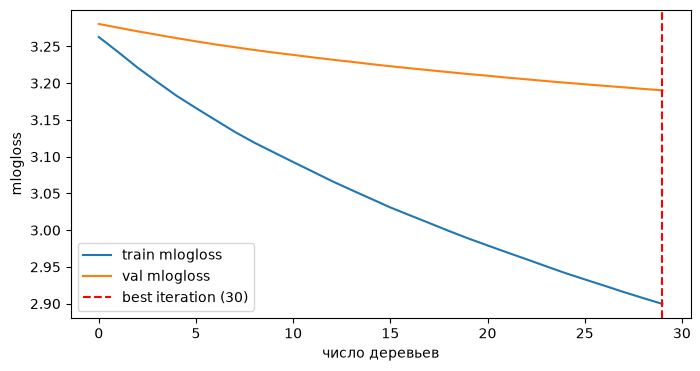

лучшие n estimators: 30
треин рок аук макро: 0.8350
тест рок аук макро: 0.8308
аккураси: 0.1998


In [ ]:
final_n_estimators = model_xgb.n_estimators
model_final = XGBClassifier(
    learning_rate=0.01,n_estimators=final_n_estimators,max_depth=5,
    min_child_weight=1,gamma=best_gamma,
    subsample=best_subsample,colsample_bytree=best_colsample_bytree,reg_alpha=best_reg_alpha,objective='multi:softprob', num_class=n,eval_metric='mlogloss',
    early_stopping_rounds=20,tree_method='hist',n_jobs=-1,random_state=67)
model_final = modelfit(model_final, X_train, y_train, X_test, y_test)

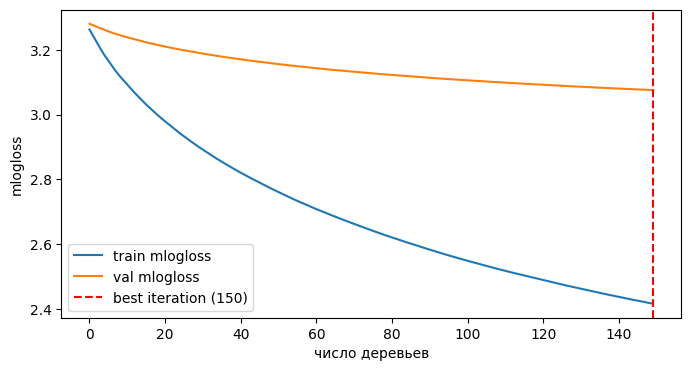

лучшие n estimators: 150
треин рок аук макро: 0.8800
тест рок аук макро: 0.8707
аккураси: 0.4066


In [8]:
model_final = XGBClassifier(
    learning_rate=0.01,n_estimators=150,max_depth=5,
    min_child_weight=1,gamma=best_gamma,
    subsample=best_subsample,colsample_bytree=best_colsample_bytree,reg_alpha=best_reg_alpha,objective='multi:softprob', num_class=n,eval_metric='mlogloss',
    early_stopping_rounds=20,tree_method='hist',n_jobs=-1,random_state=67)
model_final = modelfit(model_final, X_train, y_train, X_test, y_test)

In [9]:
le_classes = np.array([
    'ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE',
    'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION',
    'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK',
    'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT',
    'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS',
    'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS',
    'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST',
    'TRAVEL', 'U.S. NEWS', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS',
    'WOMEN', 'WORLD NEWS', 'WORLDPOST'
])

In [10]:
y_pred  = model_final.predict(X_test)
y_proba = model_final.predict_proba(X_test)

In [13]:
classes = model_final.classes_

y_test_bin = label_binarize(y_test, classes=classes)

macro_roc_auc = roc_auc_score(y_test,y_proba,multi_class='ovr',average='macro')
micro_roc_auc = roc_auc_score(y_test_bin.ravel(),y_proba.ravel())
macro_pr_auc = average_precision_score(y_test_bin,y_proba,average='macro')
micro_pr_auc = average_precision_score(y_test_bin,y_proba,average='micro')

print('макро рок-аук:', macro_roc_auc)
print('микро рок аук:', micro_roc_auc)
print('макро пр аук:', macro_pr_auc)
print('микро пр аук:', micro_pr_auc)

макро рок-аук: 0.870733940466279
микро рок аук: 0.8873068380767039
макро пр аук: 0.3483487466190027
микро пр аук: 0.4147025813593262
